In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('CompleteData.csv')

In [3]:
df.shape

(6954636, 40)

WIND_DIR               32789
WIND_SPD               32789
WIND_GUST              32789
VISIBILITY             32789
TEMPERATURE            32789
DEW_POINT              32789
REL_HUMIDITY           32789
ALTIMETER              32789
LOWEST_CLOUD_LAYER     32789
N_CLOUD_LAYER          32789
LOW_LEVEL_CLOUD        32789
MID_LEVEL_CLOUD        32789
HIGH_LEVEL_CLOUD       32789
CLOUD_COVER            32789
ACTIVE_WEATHER         32789

this columns contains null values, our dataset contains nearly 70 lakh rows, so write down code to add more null data in each and every columns, and add outliers too, so we can filter out and work on 40-50 lakhs data only.

In [4]:
columns = [
    "WIND_DIR",
    "WIND_SPD",
    "WIND_GUST",
    "VISIBILITY",
    "TEMPERATURE",
    "DEW_POINT",
    "REL_HUMIDITY",
    "ALTIMETER",
    "LOWEST_CLOUD_LAYER",
    "N_CLOUD_LAYER",
    "LOW_LEVEL_CLOUD",
    "MID_LEVEL_CLOUD",
    "HIGH_LEVEL_CLOUD",
    "CLOUD_COVER",
    "ACTIVE_WEATHER"
]

# Percentage of additional missing values
missing_percentage = 0.045   # 4.5%

np.random.seed(42)

for col in columns:
    if col in df.columns:
        random_index = df.sample(frac=missing_percentage).index
        df.loc[random_index, col] = np.nan

print("Additional missing values inserted.")

Additional missing values inserted.


In [5]:
numeric_columns = [
    "WIND_DIR",
    "WIND_SPD",
    "WIND_GUST",
    "VISIBILITY",
    "TEMPERATURE",
    "DEW_POINT",
    "REL_HUMIDITY",
    "ALTIMETER",
    "LOWEST_CLOUD_LAYER",
    "N_CLOUD_LAYER"
]

outlier_percentage = 0.05   # 5%

for col in numeric_columns:
    if col in df.columns:

        idx = df.sample(frac=outlier_percentage).index

        mean = df[col].mean(skipna=True)
        std = df[col].std(skipna=True)

        # Extreme values (about 8-12 standard deviations away)
        outliers = mean + np.random.choice([-1, 1], size=len(idx)) * (
            np.random.uniform(8, 12, len(idx)) * std
        )

        df.loc[idx, col] = outliers

print("Outliers inserted.")

Outliers inserted.


In [6]:
df.isnull().sum()

FL_DATE                     0
DEP_HOUR                    0
MKT_UNIQUE_CARRIER          0
MKT_CARRIER_FL_NUM          0
OP_UNIQUE_CARRIER           0
OP_CARRIER_FL_NUM           0
TAIL_NUM                    0
ORIGIN                      0
DEST                        0
DEP_TIME                    0
CRS_DEP_TIME                0
TAXI_OUT                    0
DEP_DELAY                   0
AIR_TIME                    0
DISTANCE                    0
CANCELLED                   0
LATITUDE                    0
LONGITUDE                   0
ELEVATION                   0
MESONET_STATION             0
YEAR OF MANUFACTURE         0
MANUFACTURER                0
ICAO TYPE                   0
RANGE                       9
WIDTH                       0
WIND_DIR               327313
WIND_SPD               327069
WIND_GUST              327078
VISIBILITY             327056
TEMPERATURE            327249
DEW_POINT              327231
REL_HUMIDITY           327031
ALTIMETER              326991
LOWEST_CLO

In [12]:
df1 = df.copy()

In [13]:
df1.to_csv("CompleteFlightData.csv", index=False)

In [15]:
ds = pd.read_csv('CompleteFlightData.csv')

In [17]:
df1.dropna(inplace = True)

In [18]:
df1.shape, df.shape

((3551256, 40), (6954636, 40))

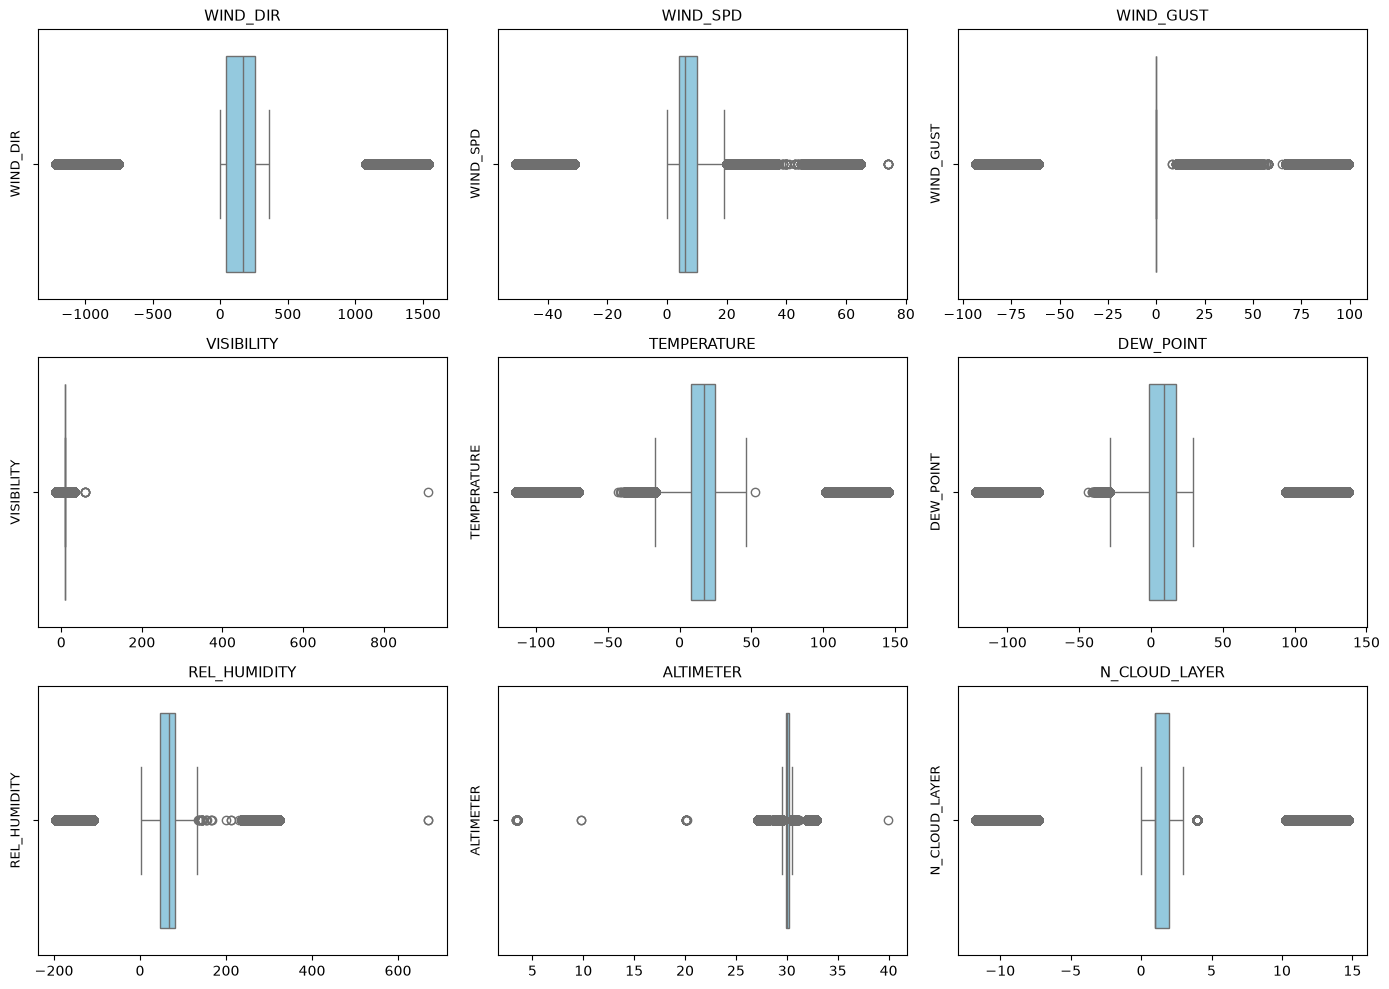

In [19]:
# Numerical columns
numeric_columns = [
    "WIND_DIR",
    "WIND_SPD",
    "WIND_GUST",
    "VISIBILITY",
    "TEMPERATURE",
    "DEW_POINT",
    "REL_HUMIDITY",
    "ALTIMETER",
    "N_CLOUD_LAYER"
]

# Create 3x3 subplot
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(
        x=df1[col],
        ax=axes[i],
        color="skyblue",
        linewidth=1
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col, fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
df_clean = df1.copy() # null removed

# Remove outliers one column at a time
for col in numeric_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_limit) &
        (df_clean[col] <= upper_limit)
    ]

print("Original Shape :", df1.shape)
print("Cleaned Shape  :", df_clean.shape)

Original Shape : (3551256, 40)
Cleaned Shape  : (1615803, 40)


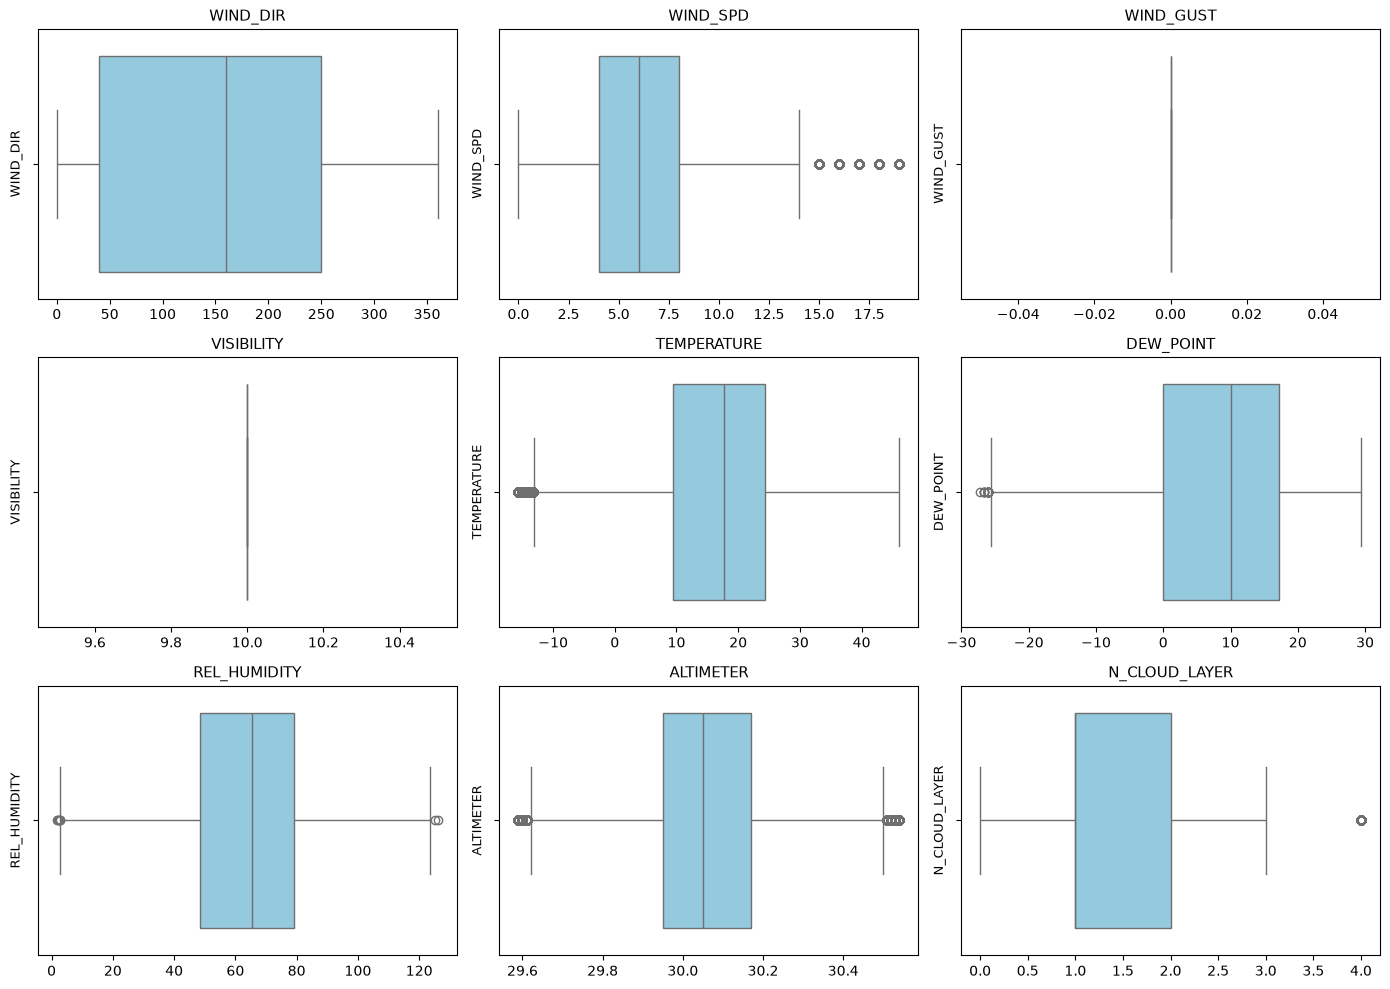

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(
        x=df_clean[col],
        ax=axes[i],
        color="skyblue",
        linewidth=1
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col, fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
df_clean.head()

,FL_DATE,DEP_HOUR,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,TAIL_NUM,ORIGIN,DEST,DEP_TIME,...,DEW_POINT,REL_HUMIDITY,ALTIMETER,LOWEST_CLOUD_LAYER,N_CLOUD_LAYER,LOW_LEVEL_CLOUD,MID_LEVEL_CLOUD,HIGH_LEVEL_CLOUD,CLOUD_COVER,ACTIVE_WEATHER
12,2022-01-01,6,AA,1019,AA,1019,N764US,SJC,DFW,2022-01-01 06:05:00,...,3.89,76.40,30.02,2000.0,1.0,1.0,0.0,0.0,1.0,0.0
17,2022-01-01,7,AA,1025,AA,1025,N572UW,TUS,DFW,2022-01-01 07:26:00,...,8.28,89.04,29.80,3300.0,1.0,1.0,0.0,0.0,4.0,1.0
19,2022-01-01,8,AA,1032,AA,1032,N771AN,JFK,MIA,2022-01-01 08:56:00,...,8.89,96.69,29.91,1000.0,2.0,1.0,0.0,0.0,4.0,0.0
20,2022-01-01,23,AA,1033,AA,1033,N770UW,CLT,IND,2022-01-01 23:26:00,...,18.28,89.81,29.79,1500.0,3.0,1.0,0.0,1.0,3.0,0.0
26,2022-01-01,20,AA,1043,AA,1043,N8009T,CLT,CLE,2022-01-01 20:58:00,...,18.28,73.49,29.80,3300.0,4.0,1.0,1.0,1.0,4.0,0.0


In [22]:
df_clean.duplicated().sum()

np.int64(0)

1. Create Weather Severity Index

This combines wind speed, visibility, humidity, and wind gust into a single feature.

In [23]:
df_clean["WEATHER_SEVERITY"] = (
    df_clean["WIND_SPD"].fillna(df_clean["WIND_SPD"].median()) * 0.35 +
    df_clean["WIND_GUST"].fillna(df_clean["WIND_GUST"].median()) * 0.35 +
    (10 - df_clean["VISIBILITY"].fillna(df_clean["VISIBILITY"].median())) * 0.20 +
    df_clean["REL_HUMIDITY"].fillna(df_clean["REL_HUMIDITY"].median()) * 0.10
)

2. Temperature Difference

Difference between air temperature and dew point.

In [24]:
df_clean["TEMP_DEW_DIFF"] = (
    df_clean["TEMPERATURE"] - df_clean["DEW_POINT"]
)

3. Wind Intensity

In [25]:
df_clean["WIND_INTENSITY"] = (
    df_clean["WIND_SPD"] + df_clean["WIND_GUST"]
)

4. Visibility Category

In [26]:
df_clean["VISIBILITY_CATEGORY"] = pd.cut(
    df_clean["VISIBILITY"],
    bins=[-1,2,5,10,20,100],
    labels=[
        "Very Poor",
        "Poor",
        "Moderate",
        "Good",
        "Excellent"
    ]
)

5. Humidity Category

In [27]:
df_clean["HUMIDITY_LEVEL"] = pd.cut(
    df_clean["REL_HUMIDITY"],
    bins=[0,30,60,80,100],
    labels=[
        "Low",
        "Normal",
        "High",
        "Very High"
    ]
)

6. Wind Direction Groups

In [28]:
def wind_direction(x):

    if pd.isna(x):
        return "Unknown"

    if x < 45 or x >= 315:
        return "North"
    elif x < 135:
        return "East"
    elif x < 225:
        return "South"
    else:
        return "West"

df_clean["WIND_DIRECTION"] = df_clean["WIND_DIR"].apply(wind_direction)

7. Cloud Density

In [29]:
cloud_cols = [
    "LOW_LEVEL_CLOUD",
    "MID_LEVEL_CLOUD",
    "HIGH_LEVEL_CLOUD"
]

df_clean["TOTAL_CLOUD"] = (
    df_clean[cloud_cols]
    .fillna(0)
    .sum(axis=1)
)

8. Encode Cloud Cover

In [30]:
le = LabelEncoder()

df_clean["CLOUD_COVER_ENCODED"] = le.fit_transform(
    df_clean["CLOUD_COVER"].astype(str)
)

In [146]:
df_clean.head()

,FL_DATE,DEP_HOUR,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,TAIL_NUM,ORIGIN,DEST,DEP_TIME,...,CLOUD_COVER,ACTIVE_WEATHER,WEATHER_SEVERITY,TEMP_DEW_DIFF,WIND_INTENSITY,VISIBILITY_CATEGORY,HUMIDITY_LEVEL,WIND_DIRECTION,TOTAL_CLOUD,CLOUD_COVER_ENCODED
17,2022-01-01,7,AA,1025,AA,1025,N572UW,TUS,DFW,2022-01-01 07:26:00,...,4.0,1.0,11.704,1.72,8.0,Moderate,Very High,South,1.0,4
26,2022-01-01,20,AA,1043,AA,1043,N8009T,CLT,CLE,2022-01-01 20:58:00,...,4.0,0.0,12.949,5.00,16.0,Moderate,High,South,3.0,4
126,2022-01-01,22,AA,1186,AA,1186,N821NN,CLT,JFK,2022-01-01 22:49:00,...,3.0,0.0,12.553,2.22,11.0,Moderate,Very High,South,3.0,3
137,2022-01-01,22,AA,1205,AA,1205,N949NN,DFW,AUS,2022-01-01 22:59:00,...,3.0,0.0,13.105,5.50,18.0,Moderate,High,North,2.0,3
144,2022-01-01,13,AA,1210,AA,1210,N554UW,SFO,PHX,2022-01-01 13:25:00,...,1.0,0.0,10.790,3.89,9.0,Moderate,High,North,1.0,1


In [35]:
df_clean.to_csv('Dataset_ModellingLead.csv')

In [166]:
df_clean.shape

(283192, 48)